# Fase 1 — Adquisición de datos y Análisis Exploratorio (EDA)

**Thesis:** Comparativa de algoritmos para la predicción de la demanda eléctrica  
**Author:** Antonio Navarro  

This notebook:
1. Downloads 5 years of ESIOS real demand (indicator 1293) at hourly resolution
2. Downloads hourly weather for 6 Spanish cities via Open-Meteo
3. Computes Spanish national + local holidays
4. Engineers the full feature set (cyclical, lags, rolling stats, HDD/CDD)
5. Performs EDA: STL decomposition, ADF stationarity test, ACF/PACF, Box-Cox, Pearson correlation
6. Splits 60/20/20 chronologically and saves CSVs to `data/`

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# ── Colab: clone or update the repo, then cd into it ──────────────────────────
REPO_NAME = "pred_demanda"
REPO_URL  = "https://github.com/antonionc/pred_demanda.git"

if os.path.exists("data_utils.py"):
    # Already inside the repo (re-run of this cell or later runs)
    !git pull
elif os.path.isdir(REPO_NAME):
    # Repo cloned but we haven't cd'd yet
    %cd {REPO_NAME}
    !git pull
elif os.path.exists(f"/content/{REPO_NAME}"):
    %cd /content/{REPO_NAME}
    !git pull
elif os.path.exists("/content"):
    # First run in Colab: clone and enter
    !git clone {REPO_URL}
    %cd {REPO_NAME}
# ──────────────────────────────────────────────────────────────────────────────

# Local utilities
sys.path.insert(0, os.path.abspath('.'))
import data_utils as du

# Mount Google Drive in Colab and create persistent links for data/, cache/, saved_models/
du.setup_colab_drive()

# Reproducibility
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_theme(style='whitegrid')

print('Environment ready.')

Cloning into 'pred_demanda'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 57 (delta 27), reused 40 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 1.50 MiB | 9.53 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/pred_demanda
Environment ready.


## 1 · Download ESIOS demand data (2020–2025)

In [2]:
START_DATE = '2020-01-01'
END_DATE   = '2025-07-31'

df_demand = du.download_esios(
    indicator_id = du.ESIOS_REAL_DEMAND,
    start_date   = START_DATE,
    end_date     = END_DATE,
    api_key_file = 'esios_api_key.txt',
)

print(f"\nDemand data shape : {df_demand.shape}")
print(f"Date range        : {df_demand['datetime'].min()} → {df_demand['datetime'].max()}")
print(f"Missing values    : {df_demand['value'].isna().sum()}")
df_demand.head()

[ESIOS] Downloading indicator 1293 (2020-01-01 → 2025-07-31) in 67 chunk(s)…
  Chunk 1/67: 2020-01-01 → 2020-01-31
  Chunk 2/67: 2020-02-01 → 2020-02-29
  Chunk 3/67: 2020-03-01 → 2020-03-31
  Chunk 4/67: 2020-04-01 → 2020-04-30
  Chunk 5/67: 2020-05-01 → 2020-05-31
  Chunk 6/67: 2020-06-01 → 2020-06-30
  Chunk 7/67: 2020-07-01 → 2020-07-31
  Chunk 8/67: 2020-08-01 → 2020-08-31
  Chunk 9/67: 2020-09-01 → 2020-09-30
  Chunk 10/67: 2020-10-01 → 2020-10-31
  Chunk 11/67: 2020-11-01 → 2020-11-30
  Chunk 12/67: 2020-12-01 → 2020-12-31
  Chunk 13/67: 2021-01-01 → 2021-01-31
  Chunk 14/67: 2021-02-01 → 2021-02-28
  Chunk 15/67: 2021-03-01 → 2021-03-31
  Chunk 16/67: 2021-04-01 → 2021-04-30
  Chunk 17/67: 2021-05-01 → 2021-05-31
  Chunk 18/67: 2021-06-01 → 2021-06-30
  Chunk 19/67: 2021-07-01 → 2021-07-31
  Chunk 20/67: 2021-08-01 → 2021-08-31
  Chunk 21/67: 2021-09-01 → 2021-09-30
  Chunk 22/67: 2021-10-01 → 2021-10-31
  Chunk 23/67: 2021-11-01 → 2021-11-30
  Chunk 24/67: 2021-12-01 → 2021-12

,datetime,value
0,2019-12-31 23:00:00+00:00,23001.000000
1,2020-01-01 00:00:00+00:00,22253.666667
2,2020-01-01 01:00:00+00:00,20999.500000
3,2020-01-01 02:00:00+00:00,19784.166667
4,2020-01-01 03:00:00+00:00,18997.333333


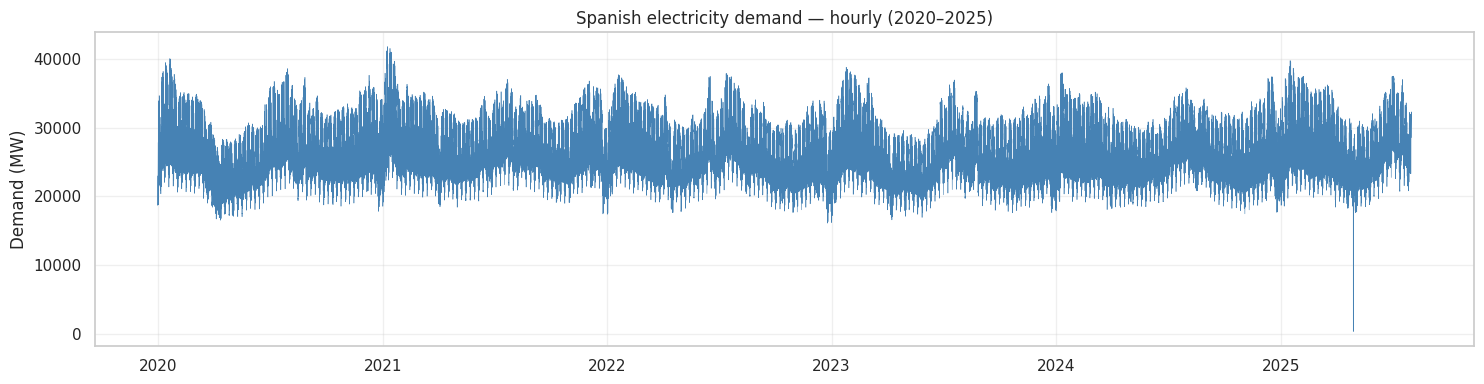

Mean : 26933 MW
Min  : 328 MW
Max  : 41829 MW
Std  : 4373 MW


In [3]:
# Quick sanity check: plot raw hourly demand
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_demand['datetime'], df_demand['value'], linewidth=0.4, color='steelblue')
ax.set_title('Spanish electricity demand — hourly (2020–2025)')
ax.set_ylabel('Demand (MW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('data/fig_raw_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean : {df_demand['value'].mean():.0f} MW")
print(f"Min  : {df_demand['value'].min():.0f} MW")
print(f"Max  : {df_demand['value'].max():.0f} MW")
print(f"Std  : {df_demand['value'].std():.0f} MW")

## 2 · Download Open-Meteo weather (6 Spanish cities)

In [4]:
df_weather = du.download_openmeteo(
    start_date = START_DATE,
    end_date   = END_DATE,
)

print(f"\nWeather data shape : {df_weather.shape}")
print(f"Columns            : {list(df_weather.columns)}")
df_weather.head()

[Weather] Downloading Madrid (2020-01-01 → 2025-07-31)…
[Weather] Downloading Barcelona (2020-01-01 → 2025-07-31)…
[Weather] Downloading Valencia (2020-01-01 → 2025-07-31)…
[Weather] Downloading Sevilla (2020-01-01 → 2025-07-31)…
[Weather] Downloading Zaragoza (2020-01-01 → 2025-07-31)…
[Weather] Downloading Málaga (2020-01-01 → 2025-07-31)…
[Weather] Downloaded 48936 hourly rows → cached.

Weather data shape : (48936, 25)
Columns            : ['datetime', 'MAD_temperature_2m', 'MAD_cloud_cover', 'MAD_wind_speed_10m', 'MAD_surface_pressure', 'BCN_temperature_2m', 'BCN_cloud_cover', 'BCN_wind_speed_10m', 'BCN_surface_pressure', 'VLC_temperature_2m', 'VLC_cloud_cover', 'VLC_wind_speed_10m', 'VLC_surface_pressure', 'SEV_temperature_2m', 'SEV_cloud_cover', 'SEV_wind_speed_10m', 'SEV_surface_pressure', 'ZGZ_temperature_2m', 'ZGZ_cloud_cover', 'ZGZ_wind_speed_10m', 'ZGZ_surface_pressure', 'MLG_temperature_2m', 'MLG_cloud_cover', 'MLG_wind_speed_10m', 'MLG_surface_pressure']


,datetime,MAD_temperature_2m,MAD_cloud_cover,MAD_wind_speed_10m,MAD_surface_pressure,BCN_temperature_2m,BCN_cloud_cover,BCN_wind_speed_10m,BCN_surface_pressure,VLC_temperature_2m,...,SEV_wind_speed_10m,SEV_surface_pressure,ZGZ_temperature_2m,ZGZ_cloud_cover,ZGZ_wind_speed_10m,ZGZ_surface_pressure,MLG_temperature_2m,MLG_cloud_cover,MLG_wind_speed_10m,MLG_surface_pressure
0,2020-01-01 00:00:00+00:00,1.3,0,7.2,952.2,5.6,0,10.0,1028.9,6.5,...,8.2,1029.4,-0.2,3,3.7,1008.6,11.5,98,8.0,1030.4
1,2020-01-01 01:00:00+00:00,1.5,0,6.2,952.2,4.2,0,9.0,1028.5,5.4,...,7.6,1028.8,-1.4,3,4.7,1008.3,11.4,94,7.2,1029.8
2,2020-01-01 02:00:00+00:00,0.7,0,5.4,951.9,3.6,0,8.4,1028.5,5.0,...,7.9,1028.6,-0.7,2,5.4,1008.0,11.6,70,6.8,1029.6
3,2020-01-01 03:00:00+00:00,0.2,0,6.6,952.2,3.4,0,7.9,1028.4,4.5,...,8.2,1028.8,-0.9,37,4.7,1007.9,11.4,27,7.9,1029.7
4,2020-01-01 04:00:00+00:00,-0.7,0,6.1,951.9,3.2,0,7.1,1028.6,4.3,...,8.2,1028.5,-0.8,30,3.7,1007.9,10.7,23,8.0,1029.3


## 3 · Spanish holidays

In [5]:
holidays = du.compute_spanish_holidays(start_year=2020, end_year=2025)
print(f"Total holiday entries (2020–2025): {len(holidays)}")
# Show a sample
for k, v in list(holidays.items())[:10]:
    print(f"  {k}: {v}")

Total holiday entries (2020–2025): 108
  2020-01-01: Año Nuevo
  2020-01-06: Reyes Magos
  2020-04-10: Viernes Santo
  2020-05-01: Día del Trabajo
  2020-08-15: Asunción de la Virgen
  2020-10-12: Virgen del Pilar (ZGZ)
  2020-11-01: Todos los Santos
  2020-12-06: Día de la Constitución
  2020-12-08: Inmaculada Concepción
  2020-12-25: Navidad


## 4 · Feature engineering

In [6]:
df = du.build_hourly_features(
    df_demand  = df_demand,
    df_weather = df_weather,
    df_holidays= holidays,
)

print(f"\nFull feature dataset: {df.shape}")
print(f"Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c}")


Full feature dataset: (48766, 48)
Columns (48):
  datetime
  demand_mw
  MAD_temperature_2m
  MAD_cloud_cover
  MAD_wind_speed_10m
  MAD_surface_pressure
  BCN_temperature_2m
  BCN_cloud_cover
  BCN_wind_speed_10m
  BCN_surface_pressure
  VLC_temperature_2m
  VLC_cloud_cover
  VLC_wind_speed_10m
  VLC_surface_pressure
  SEV_temperature_2m
  SEV_cloud_cover
  SEV_wind_speed_10m
  SEV_surface_pressure
  ZGZ_temperature_2m
  ZGZ_cloud_cover
  ZGZ_wind_speed_10m
  ZGZ_surface_pressure
  MLG_temperature_2m
  MLG_cloud_cover
  MLG_wind_speed_10m
  MLG_surface_pressure
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  doy_sin
  doy_cos
  month_sin
  month_cos
  is_weekday
  is_saturday
  is_sunday
  is_national_holiday
  is_any_holiday
  demand_lag_1h
  demand_lag_24h
  demand_lag_168h
  demand_roll24_mean
  demand_roll24_std
  demand_roll168_mean
  demand_roll168_std
  hdd
  cdd


In [7]:
# Check for remaining NaNs
nan_counts = df.isna().sum()
if nan_counts.any():
    print('Columns with NaN:')
    print(nan_counts[nan_counts > 0])
else:
    print('No NaN values — dataset is clean.')
df.describe().T

No NaN values — dataset is clean.


,count,mean,std,min,25%,50%,75%,max
demand_mw,48766.0,26931.636148,4370.519607,327.666667,23417.041667,2.689883e+04,30204.375000,41828.833333
MAD_temperature_2m,48766.0,15.740214,9.098505,-11.100000,8.800000,1.440000e+01,22.200000,41.500000
MAD_cloud_cover,48766.0,46.509330,42.259060,0.000000,0.000000,3.800000e+01,97.000000,100.000000
MAD_wind_speed_10m,48766.0,10.360513,6.031453,0.000000,5.800000,9.100000e+00,14.000000,48.200000
MAD_surface_pressure,48766.0,942.039095,5.668536,913.300000,939.000000,9.421000e+02,945.600000,961.400000
BCN_temperature_2m,48766.0,16.785484,6.771223,-0.600000,11.700000,1.650000e+01,22.200000,37.200000
BCN_cloud_cover,48766.0,48.156297,40.773094,0.000000,5.000000,4.100000e+01,96.000000,100.000000
BCN_wind_speed_10m,48766.0,9.656870,5.811058,0.000000,5.400000,8.200000e+00,13.000000,51.100000
BCN_surface_pressure,48766.0,1014.634262,6.758871,981.400000,1011.000000,1.014500e+03,1018.500000,1037.200000
VLC_temperature_2m,48766.0,18.382147,6.621766,0.100000,13.300000,1.810000e+01,23.600000,42.400000


## 5 · EDA
### 5.1 STL Decomposition

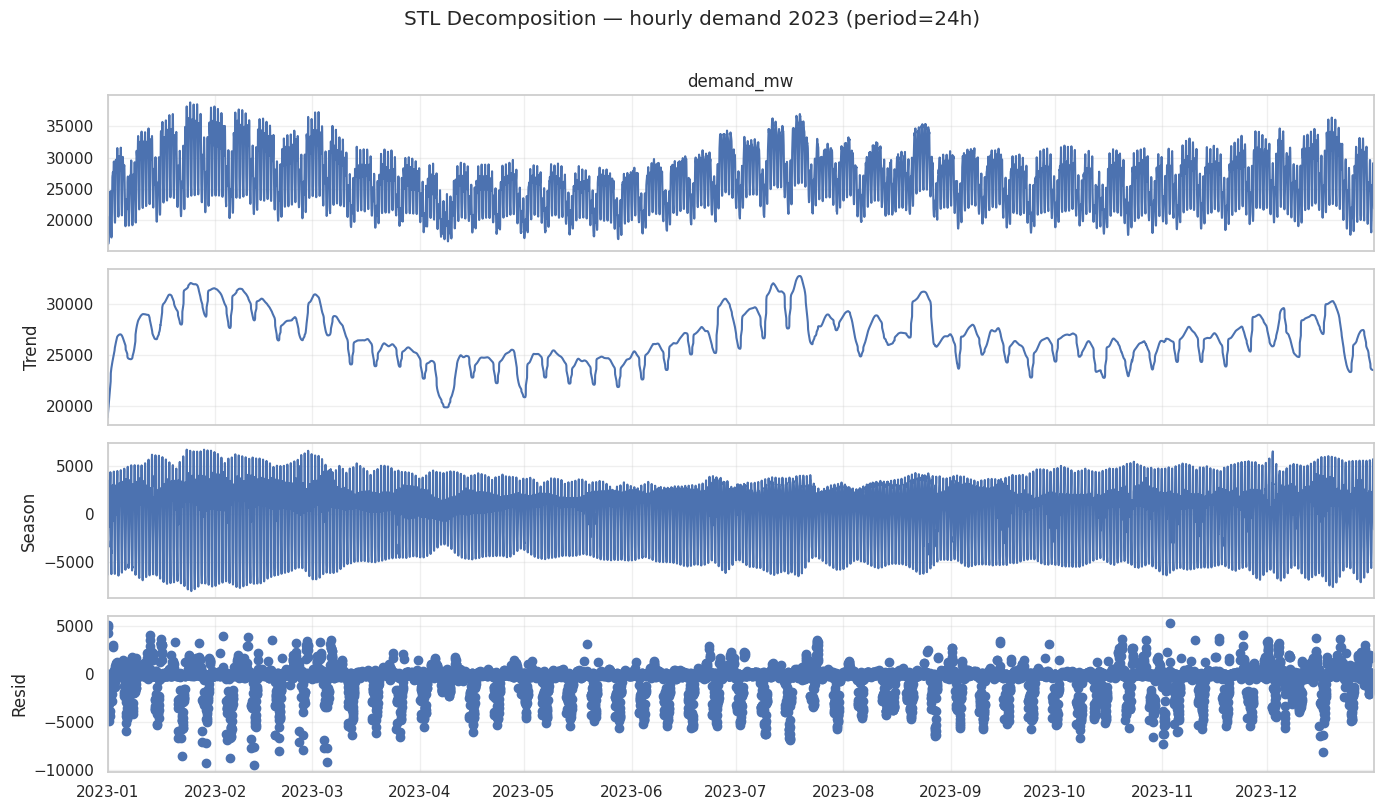

Trend  range : 18882 – 32740 MW
Seasonal std : 3192 MW
Residual std : 1536 MW


In [8]:
# STL on a representative year (2023) to keep computation manageable
ts_2023 = (
    df[df['datetime'].dt.year == 2023]
    .set_index('datetime')['demand_mw']
)

stl = STL(ts_2023, period=24, robust=True)  # period=24 → daily seasonality
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 8)
fig.suptitle('STL Decomposition — hourly demand 2023 (period=24h)', y=1.01)
plt.tight_layout()
plt.savefig('data/fig_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Trend  range : {res.trend.min():.0f} – {res.trend.max():.0f} MW")
print(f"Seasonal std : {res.seasonal.std():.0f} MW")
print(f"Residual std : {res.resid.std():.0f} MW")

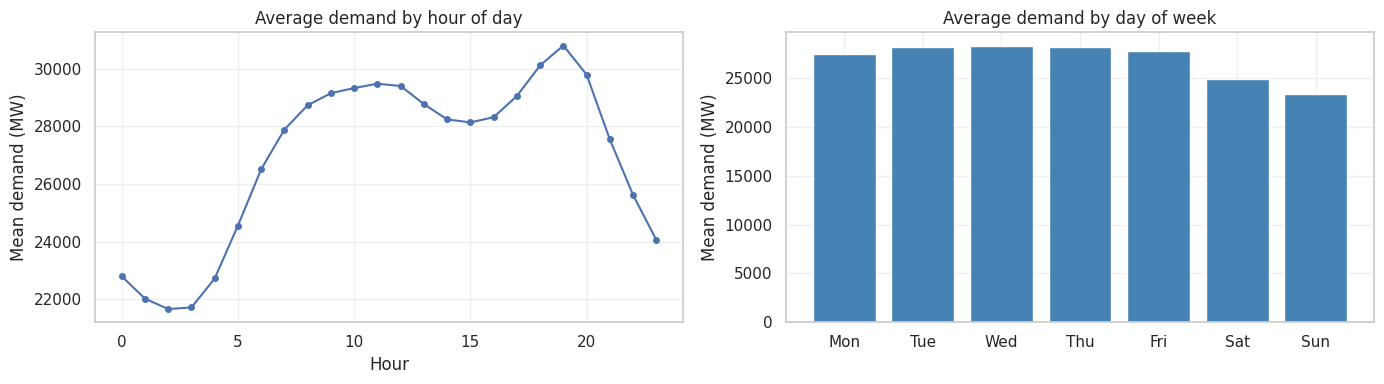

In [9]:
# Weekly seasonality — average demand by hour of day
df['hour'] = pd.to_datetime(df['datetime']).dt.hour
df['dow']  = pd.to_datetime(df['datetime']).dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_avg = df.groupby('hour')['demand_mw'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', markersize=4)
axes[0].set_title('Average demand by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean demand (MW)')

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = df.groupby('dow')['demand_mw'].mean()
axes[1].bar(day_names, dow_avg.values, color='steelblue')
axes[1].set_title('Average demand by day of week')
axes[1].set_ylabel('Mean demand (MW)')

plt.tight_layout()
plt.savefig('data/fig_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Stationarity — Augmented Dickey-Fuller test

In [10]:
series = df['demand_mw'].dropna()

result = adfuller(series, autolag='AIC')
print('Augmented Dickey-Fuller Test')
print(f'  Test statistic : {result[0]:.4f}')
print(f'  p-value        : {result[1]:.6f}')
print(f'  # lags used    : {result[2]}')
print(f'  # observations : {result[3]}')
for k, v in result[4].items():
    print(f'  Critical value ({k}): {v:.4f}')

if result[1] < 0.05:
    print('\n→ Series is STATIONARY (reject H0 at 5% level)')
else:
    print('\n→ Series is NON-STATIONARY (fail to reject H0)')

Augmented Dickey-Fuller Test
  Test statistic : -16.4146
  p-value        : 0.000000
  # lags used    : 57
  # observations : 48708
  Critical value (1%): -3.4305
  Critical value (5%): -2.8616
  Critical value (10%): -2.5668

→ Series is STATIONARY (reject H0 at 5% level)


### 5.3 ACF and PACF

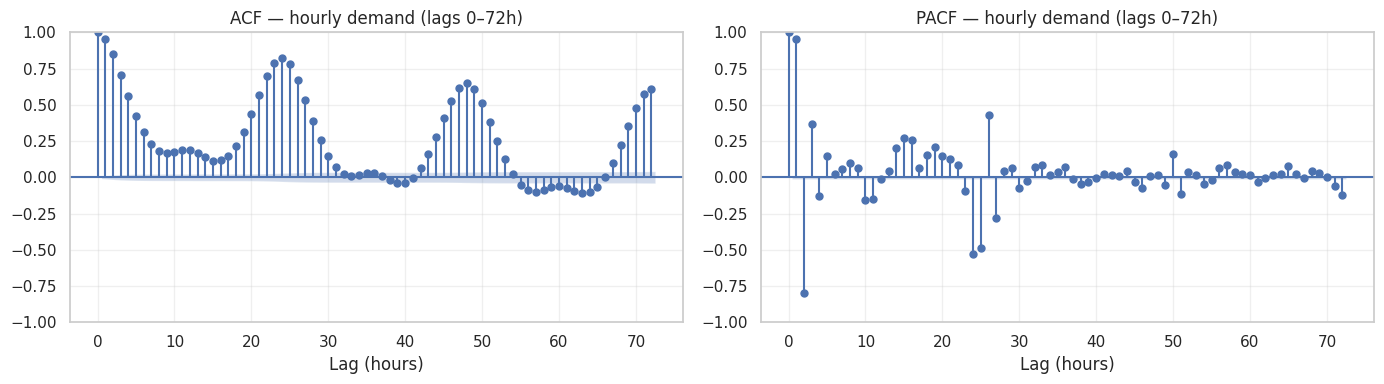

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( series, lags=72, ax=axes[0], alpha=0.05)
plot_pacf(series, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[0].set_title('ACF — hourly demand (lags 0–72h)')
axes[1].set_title('PACF — hourly demand (lags 0–72h)')
for ax in axes:
    ax.set_xlabel('Lag (hours)')
plt.tight_layout()
plt.savefig('data/fig_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Box-Cox test (variance stabilisation)

Optimal Box-Cox lambda: 0.6927
(λ≈1 → no transformation needed; λ≈0 → log transform)


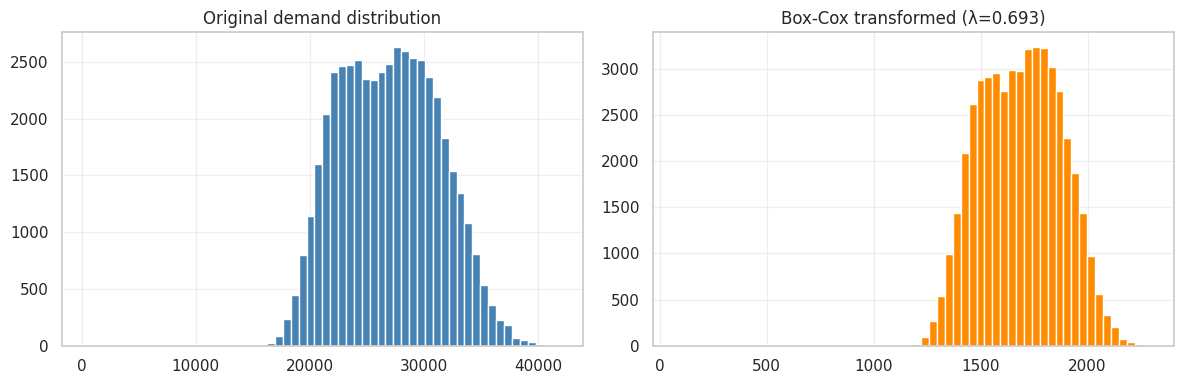

In [12]:
transformed, lam = stats.boxcox(series.values)
print(f'Optimal Box-Cox lambda: {lam:.4f}')
print('(λ≈1 → no transformation needed; λ≈0 → log transform)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(series.values,  bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Original demand distribution')
axes[1].hist(transformed, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title(f'Box-Cox transformed (λ={lam:.3f})')
plt.tight_layout()
plt.savefig('data/fig_boxcox.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Pearson correlation — demand vs exogenous variables

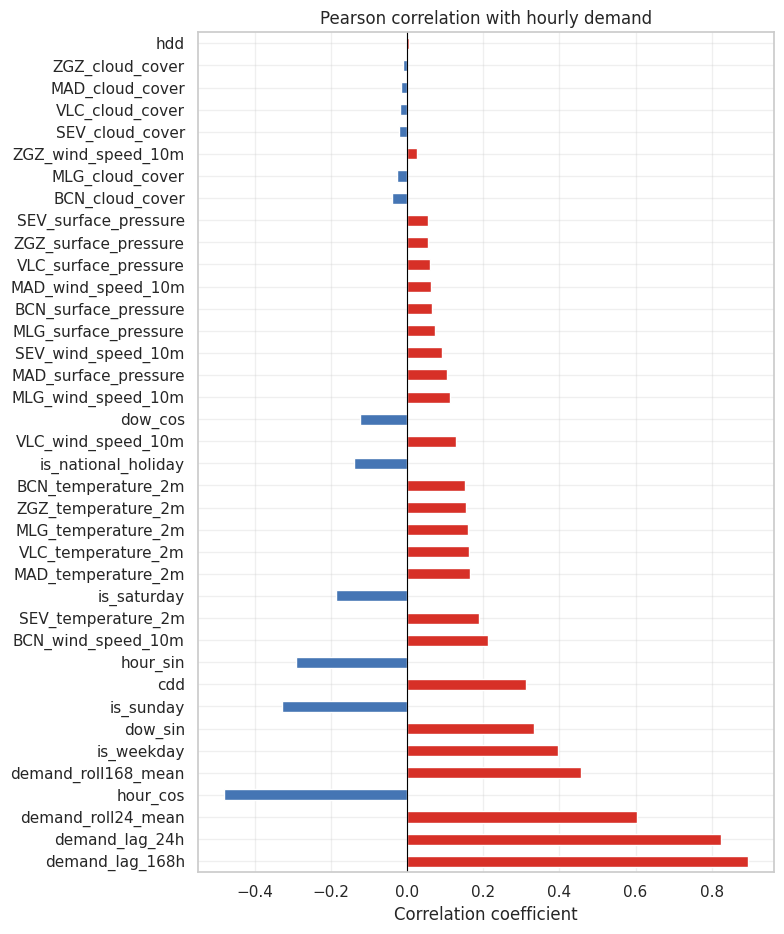


Top 10 features by |correlation|:
demand_lag_168h        0.894862
demand_lag_24h         0.824479
demand_roll24_mean     0.602759
hour_cos              -0.480306
demand_roll168_mean    0.455512
is_weekday             0.397261
dow_sin                0.333355
is_sunday             -0.327433
cdd                    0.312013
hour_sin              -0.292686


In [13]:
# Select a subset of features for correlation analysis
exog_cols = (
    [f"{c}_{v}" for c in du.CITIES for v in du.WEATHER_VARS]
    + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'is_weekday', 'is_saturday', 'is_sunday', 'is_national_holiday',
       'demand_lag_24h', 'demand_lag_168h',
       'demand_roll24_mean', 'demand_roll168_mean', 'hdd', 'cdd']
)
exog_cols = [c for c in exog_cols if c in df.columns]

corr = df[['demand_mw'] + exog_cols].corr()['demand_mw'].drop('demand_mw').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, max(5, len(corr) * 0.25)))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with hourly demand')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('data/fig_pearson_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features by |correlation|:')
print(corr.head(10).to_string())

## 6 · Chronological split (60 / 20 / 20) and save to `data/`

In [14]:
df_train, df_val, df_test = du.chronological_split(df, train_frac=0.60, val_frac=0.20)

print(f"\nTrain : {df_train['datetime'].min().date()} → {df_train['datetime'].max().date()}")
print(f"Val   : {df_val['datetime'].min().date()} → {df_val['datetime'].max().date()}")
print(f"Test  : {df_test['datetime'].min().date()} → {df_test['datetime'].max().date()}")

Split: train=29,259  val=9,753  test=9,754 rows  (60/20/20 %)

Train : 2020-01-08 → 2023-05-11
Val   : 2023-05-11 → 2024-06-20
Test  : 2024-06-20 → 2025-07-31


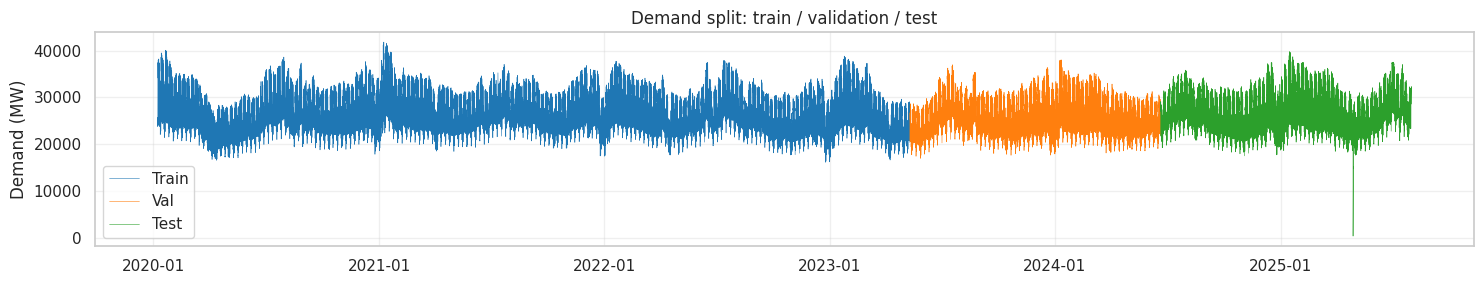

In [15]:
# Visualise the split
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(df_train['datetime'], df_train['demand_mw'], color='#1f77b4', linewidth=0.4, label='Train')
ax.plot(df_val['datetime'],   df_val['demand_mw'],   color='#ff7f0e', linewidth=0.4, label='Val')
ax.plot(df_test['datetime'],  df_test['demand_mw'],  color='#2ca02c', linewidth=0.4, label='Test')
ax.set_title('Demand split: train / validation / test')
ax.set_ylabel('Demand (MW)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('data/fig_data_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save full feature dataset and splits
df.to_csv('data/hourly_features_full.csv', index=False)
df_train.to_csv('data/features_train.csv', index=False)
df_val.to_csv(  'data/features_val.csv',   index=False)
df_test.to_csv( 'data/features_test.csv',  index=False)

print('Saved:')
for name, d in [('full', df), ('train', df_train), ('val', df_val), ('test', df_test)]:
    path = f'data/hourly_features_full.csv' if name == 'full' else f'data/features_{name}.csv'
    size_mb = os.path.getsize(path) / 1024**2
    print(f"  data/{'hourly_features_full.csv' if name == 'full' else f'features_{name}.csv'} — {len(d):,} rows — {size_mb:.1f} MB")

Saved:
  data/hourly_features_full.csv — 48,766 rows — 20.8 MB
  data/features_train.csv — 29,259 rows — 12.5 MB
  data/features_val.csv — 9,753 rows — 4.2 MB
  data/features_test.csv — 9,754 rows — 4.2 MB


## Summary

| Dataset  | Rows  | Date range |
|----------|-------|------------|
| Train    | ~29k  | 2020-01 → 2023-03 |
| Val      | ~9.7k | 2023-03 → 2024-03 |
| Test     | ~9.7k | 2024-03 → 2025-07 |

**Key EDA findings** (fill in after running):
- ADF p-value: …  (stationary / non-stationary)
- Box-Cox λ: … (transformation needed?)
- Top correlated features: demand_lag_24h, demand_roll24_mean, temperature, hour_cos…
- Dominant seasonalities: 24h (daily), 168h (weekly), annual

Next step → `fase2_1_sarimax.ipynb`